In [60]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [61]:
df = pd.read_csv('../../data/processed/m5_dataset.csv')
df.head()

,date,budget_funds_date,budget_funds_total_mln_rub,federal_budget_funds_mln_rub,regional_local_budget_funds_mln_rub,other_budget_funds_mln_rub,extra_budgetary_funds_mln_rub,liquidity_deficit_surplus_bln_rub,liquidity_deficit_surplus_without_correspondent_accounts_bln_rub,cbr_claims_standard_instruments_bln_rub,...,secured_loans_standing_bln_rub,cbr_liabilities_standard_instruments_bln_rub,deposit_auctions_bln_rub,deposit_standing_bln_rub,cobr_bln_rub,nonstandard_refundable_operations_bln_rub,correspondent_accounts_bln_rub,required_reserves_avg_bln_rub,source_budget_file,source_liquidity_file
0,03-02-2014,01-02-2014,56508.0,11170.0,803.0,44319.0,216.0,3899.1,4215.4,4338.3,...,595.3,126.0,0.0,126.0,0.0,3.1,1142.1,825.8,cbr_budget_funds.xlsx,cbr_liquidity.html
1,04-02-2014,01-02-2014,56508.0,11170.0,803.0,44319.0,216.0,3803.9,4121.9,4177.5,...,601.9,58.7,0.0,58.7,0.0,3.1,1143.8,825.8,cbr_budget_funds.xlsx,cbr_liquidity.html
2,05-02-2014,01-02-2014,56508.0,11170.0,803.0,44319.0,216.0,3673.8,4063.3,4122.8,...,594.7,62.6,0.0,62.6,0.0,3.1,1215.3,825.8,cbr_budget_funds.xlsx,cbr_liquidity.html
3,06-02-2014,01-02-2014,56508.0,11170.0,803.0,44319.0,216.0,3599.4,3667.5,3728.0,...,592.6,63.6,0.0,63.6,0.0,3.1,893.9,825.8,cbr_budget_funds.xlsx,cbr_liquidity.html
4,07-02-2014,01-02-2014,56508.0,11170.0,803.0,44319.0,216.0,3478.1,3581.5,3646.5,...,529.4,68.1,0.0,68.1,0.0,3.1,929.2,825.8,cbr_budget_funds.xlsx,cbr_liquidity.html


In [62]:
df.columns

Index(['date', 'budget_funds_date', 'budget_funds_total_mln_rub',
       'federal_budget_funds_mln_rub', 'regional_local_budget_funds_mln_rub',
       'other_budget_funds_mln_rub', 'extra_budgetary_funds_mln_rub',
       'liquidity_deficit_surplus_bln_rub',
       'liquidity_deficit_surplus_without_correspondent_accounts_bln_rub',
       'cbr_claims_standard_instruments_bln_rub',
       'repo_fx_swap_auctions_bln_rub', 'secured_loans_auctions_bln_rub',
       'repo_fx_swap_standing_bln_rub', 'secured_loans_standing_bln_rub',
       'cbr_liabilities_standard_instruments_bln_rub',
       'deposit_auctions_bln_rub', 'deposit_standing_bln_rub', 'cobr_bln_rub',
       'nonstandard_refundable_operations_bln_rub',
       'correspondent_accounts_bln_rub', 'required_reserves_avg_bln_rub',
       'source_budget_file', 'source_liquidity_file'],
      dtype='str')

In [63]:
import pandas as pd
import numpy as np

# ШАГ 1: Предобработка, сортировка и унификация данных
df_filtered = df[['date', 'budget_funds_total_mln_rub', 'liquidity_deficit_surplus_bln_rub']].copy()

# Приведение даты к datetime и ОБЯЗАТЕЛЬНАЯ сортировка
df_filtered['date'] = pd.to_datetime(df_filtered['date'], format='%d-%m-%Y', dayfirst=True, errors='coerce')
df_filtered = df_filtered.sort_values('date').reset_index(drop=True)

# ЖЕСТКОЕ масштабирование budget_funds_total_mln_rub
# Если максимальное значение больше 100 000, это сырые миллионы, делим на 1000
max_val = df_filtered['budget_funds_total_mln_rub'].abs().max()

if max_val > 100000:
    df_filtered['budget_funds_bln_rub'] = df_filtered['budget_funds_total_mln_rub'] / 1000
    print(f'Масштаб: Разделили на 1000. Максимум был {max_val:.0f}')
else:
    df_filtered['budget_funds_bln_rub'] = df_filtered['budget_funds_total_mln_rub']
    print(f'Масштаб: Оставили как есть. Максимум {max_val:.0f}')

# Удалим старую колонку
df_filtered.drop(columns=['budget_funds_total_mln_rub'], inplace=True)

# Forward-fill (растягиваем месячные данные на каждый день)
df_filtered['budget_funds_bln_rub'] = df_filtered['budget_funds_bln_rub'].ffill()


# ШАГ 2: Feature Engineering (Расчет дельт)
# Так как данные отсортированы по дням, diff(7) = минус 7 дней
df_filtered['budget_delta_7d'] = df_filtered['budget_funds_bln_rub'].diff(periods=7)
df_filtered['budget_delta_30d'] = df_filtered['budget_funds_bln_rub'].diff(periods=30)


# ШАГ 3: Квантильный триггер оттока (Flag_Budget_Drain)
# Берем 5% самых сильных падений (оттоков)
threshold_5th = df_filtered['budget_delta_7d'].quantile(0.05)
print(f'Квантильный порог оттока (5-й перцентиль): {threshold_5th:.2f} млрд руб.')

# Ставим 1, если дельта меньше или равна порогу (то есть отток сильнее порога)
df_filtered['Flag_Budget_Drain'] = (df_filtered['budget_delta_7d'] <= threshold_5th).astype(int)


# ШАГ 4: MAD-нормализация
epsilon = 1e-6
df_filtered.set_index('date', inplace=True) # Переводим дату в индекс для rolling

# Для budget_funds_bln_rub
rolling_median_budget = df_filtered['budget_funds_bln_rub'].rolling('1095D').median()
rolling_mad_budget = (df_filtered['budget_funds_bln_rub'] - rolling_median_budget).abs().rolling('1095D').median()
df_filtered['MAD_score_Budget'] = (df_filtered['budget_funds_bln_rub'] - rolling_median_budget) / (rolling_mad_budget + epsilon)
df_filtered['MAD_score_Budget'] = np.clip(df_filtered['MAD_score_Budget'], -20, 20)

# Для liquidity_deficit_surplus_bln_rub
rolling_median_liq = df_filtered['liquidity_deficit_surplus_bln_rub'].rolling('1095D').median()
rolling_mad_liq = (df_filtered['liquidity_deficit_surplus_bln_rub'] - rolling_median_liq).abs().rolling('1095D').median()
df_filtered['MAD_score_Liquidity'] = (df_filtered['liquidity_deficit_surplus_bln_rub'] - rolling_median_liq) / (rolling_mad_liq + epsilon)
df_filtered['MAD_score_Liquidity'] = np.clip(df_filtered['MAD_score_Liquidity'], -20, 20)

# Возвращаем дату обратно в колонки
df_filtered.reset_index(inplace=True)

# Проверка финальных колонок
print("\nУспех! Финальные колонки М5:")
print(df_filtered.columns.tolist())

Масштаб: Разделили на 1000. Максимум был 241474
Квантильный порог оттока (5-й перцентиль): -12.47 млрд руб.

Успех! Финальные колонки М5:
['date', 'liquidity_deficit_surplus_bln_rub', 'budget_funds_bln_rub', 'budget_delta_7d', 'budget_delta_30d', 'Flag_Budget_Drain', 'MAD_score_Budget', 'MAD_score_Liquidity']


In [64]:
# ШАГ 2: Feature Engineering (Расчет дельт)
# Установим date как индекс для расчетов diff
df_filtered.set_index('date', inplace=True)

# Недельное изменение
df_filtered['budget_delta_7d'] = df_filtered['budget_funds_bln_rub'].diff(periods=7)

# Месячное изменение
df_filtered['budget_delta_30d'] = df_filtered['budget_funds_bln_rub'].diff(periods=30)

# Сбросим индекс
df_filtered.reset_index(inplace=True)

In [65]:
# ШАГ 3: Создание триггера Flag_Budget_Drain
threshold_5pct = df_filtered['budget_delta_7d'].quantile(0.05)

# Адаптивный триггер: 1, если недельная дельта ниже 5-го перцентиля
# Это позволяет работать с любым масштабом данных
threshold_5pct = threshold_5pct if pd.notna(threshold_5pct) else -400

df_filtered['Flag_Budget_Drain'] = (df_filtered['budget_delta_7d'] < threshold_5pct).astype(int)
print(f'Flag_Budget_Drain threshold (5th percentile) = {threshold_5pct:.2f}')

Flag_Budget_Drain threshold (5th percentile) = -12.47


In [66]:
# ШАГ 4: MAD-нормализация
epsilon = 1e-6

# Установим date как индекс для rolling
df_filtered.set_index('date', inplace=True)

# Для budget_funds_bln_rub
rolling_median_budget = df_filtered['budget_funds_bln_rub'].rolling('1095D').median()
rolling_mad_budget = (df_filtered['budget_funds_bln_rub'] - rolling_median_budget).abs().rolling('1095D').median()
df_filtered['MAD_score_Budget'] = (df_filtered['budget_funds_bln_rub'] - rolling_median_budget) / (rolling_mad_budget + epsilon)
df_filtered['MAD_score_Budget'] = np.clip(df_filtered['MAD_score_Budget'], -20, 20)

# Для liquidity_deficit_surplus_bln_rub
rolling_median_liq = df_filtered['liquidity_deficit_surplus_bln_rub'].rolling('1095D').median()
rolling_mad_liq = (df_filtered['liquidity_deficit_surplus_bln_rub'] - rolling_median_liq).abs().rolling('1095D').median()
df_filtered['MAD_score_Liquidity'] = (df_filtered['liquidity_deficit_surplus_bln_rub'] - rolling_median_liq) / (rolling_mad_liq + epsilon)
df_filtered['MAD_score_Liquidity'] = np.clip(df_filtered['MAD_score_Liquidity'], -20, 20)

# Сбросим индекс
df_filtered.reset_index(inplace=True)

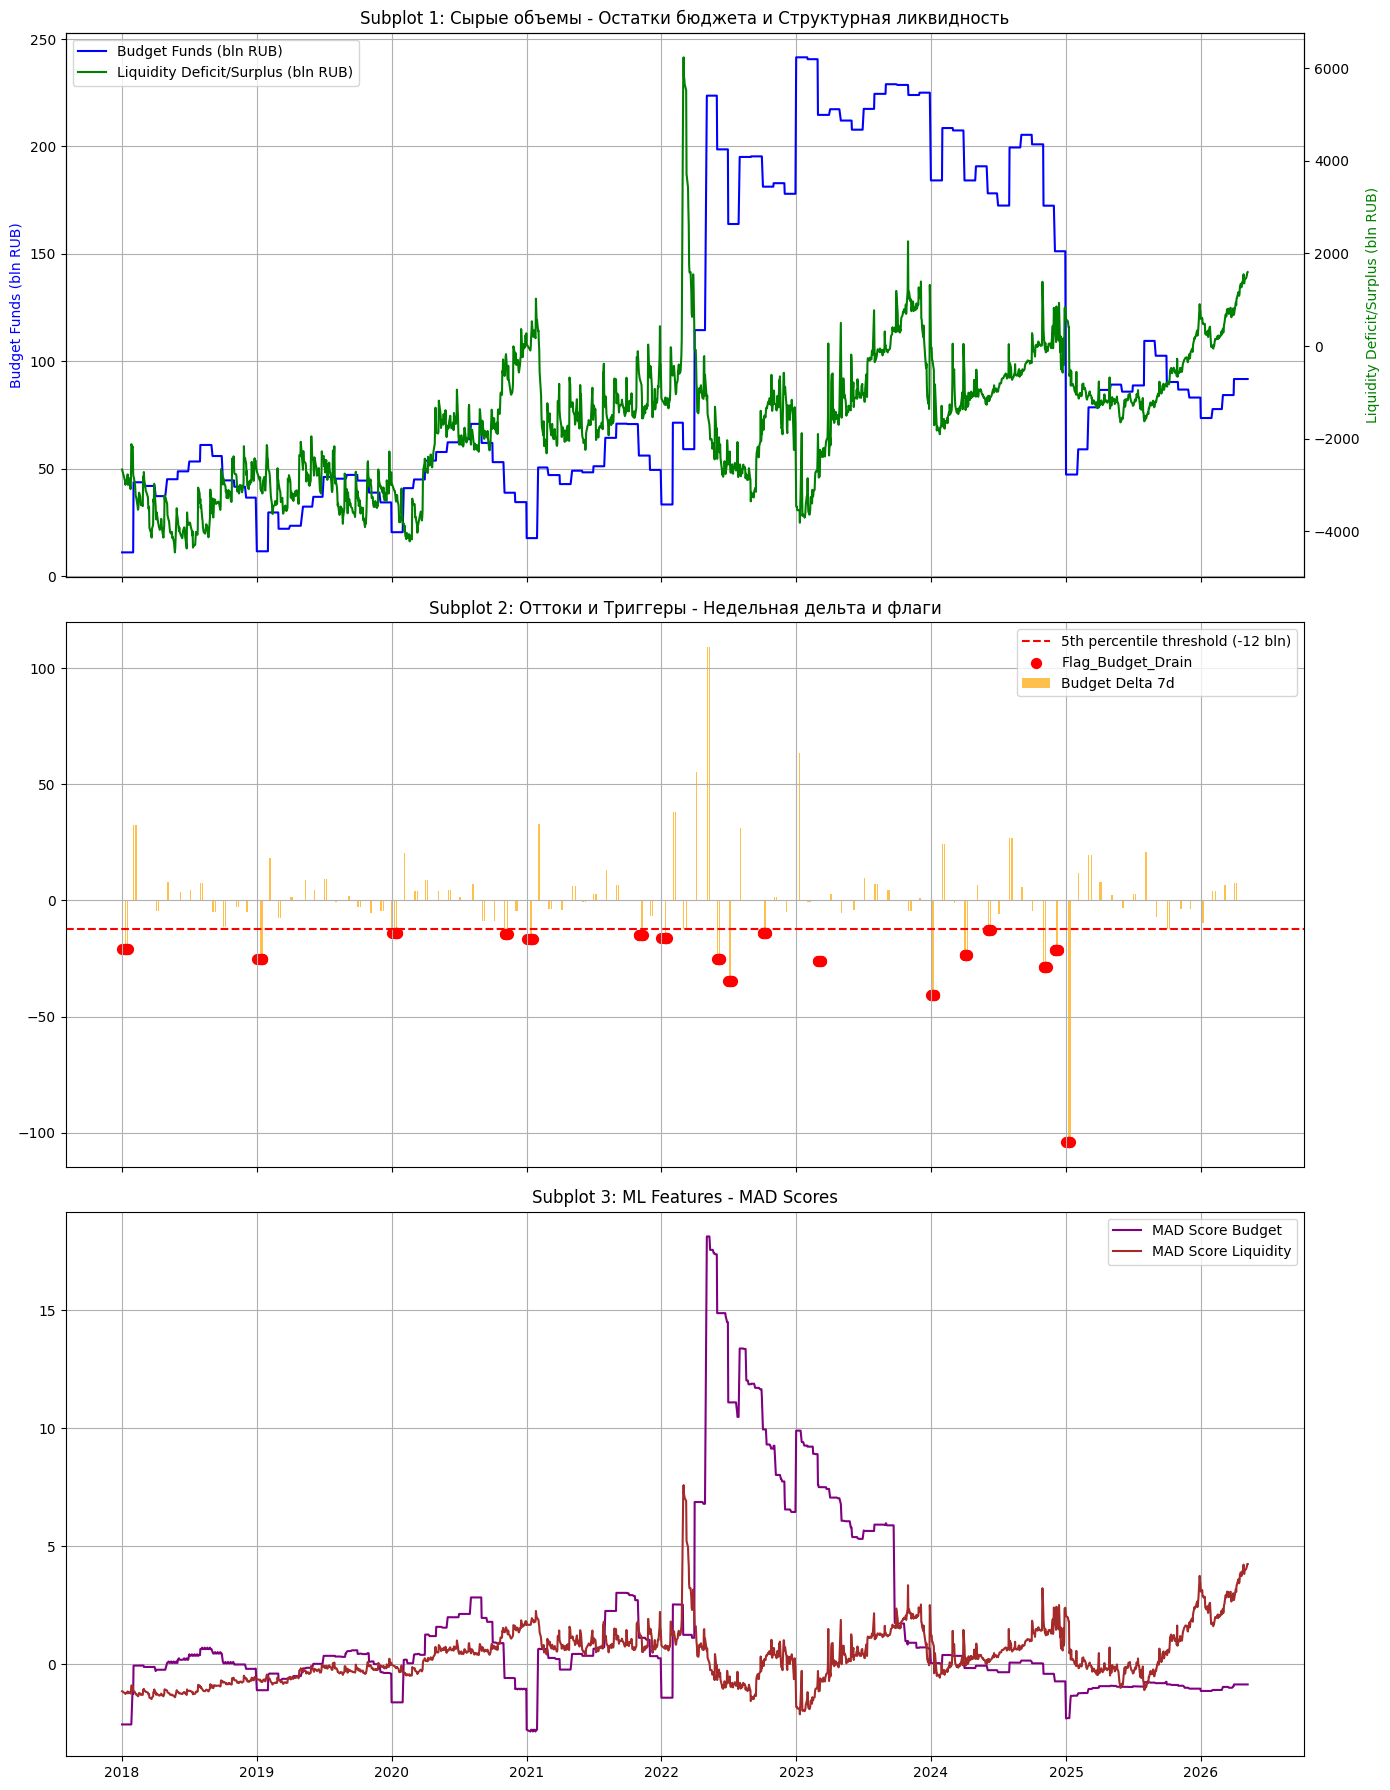

In [67]:
# ШАГ 5: Визуализация для дашборда
# Фильтр по годам 2018-2026
df_plot = df_filtered[(df_filtered['date'].dt.year >= 2018) & (df_filtered['date'].dt.year <= 2026)].copy()

fig, axes = plt.subplots(3, 1, figsize=(14, 18), sharex=True)

# Subplot 1: Сырые объемы
ax1 = axes[0]
ax2 = ax1.twinx()

ax1.plot(df_plot['date'], df_plot['budget_funds_bln_rub'], label='Budget Funds (bln RUB)', color='blue')
ax2.plot(df_plot['date'], df_plot['liquidity_deficit_surplus_bln_rub'], label='Liquidity Deficit/Surplus (bln RUB)', color='green')

ax1.set_ylabel('Budget Funds (bln RUB)', color='blue')
ax2.set_ylabel('Liquidity Deficit/Surplus (bln RUB)', color='green')
ax1.set_title('Subplot 1: Сырые объемы - Остатки бюджета и Структурная ликвидность')
ax1.grid(True)

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax2.get_legend_handles_labels()
ax1.legend(lines_1 + lines_2, labels_1 + labels_2, loc='upper left')

# Subplot 2: Оттоки и Триггеры
axes[1].bar(df_plot['date'], df_plot['budget_delta_7d'], label='Budget Delta 7d', color='orange', alpha=0.7)
axes[1].axhline(y=threshold_5pct, color='red', linestyle='--', label=f'5th percentile threshold ({threshold_5pct:.0f} bln)')
# Красные точки для Flag_Budget_Drain
flag_dates = df_plot[df_plot['Flag_Budget_Drain'] == 1]['date']
flag_values = df_plot[df_plot['Flag_Budget_Drain'] == 1]['budget_delta_7d']
axes[1].scatter(flag_dates, flag_values, color='red', s=50, label='Flag_Budget_Drain')
axes[1].set_title('Subplot 2: Оттоки и Триггеры - Недельная дельта и флаги')
axes[1].legend()
axes[1].grid(True)

# Subplot 3: ML Features
axes[2].plot(df_plot['date'], df_plot['MAD_score_Budget'], label='MAD Score Budget', color='purple')
axes[2].plot(df_plot['date'], df_plot['MAD_score_Liquidity'], label='MAD Score Liquidity', color='brown')
axes[2].set_title('Subplot 3: ML Features - MAD Scores')
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()

In [68]:
# Финальный DataFrame df_m5
df_m5 = df_filtered.copy()
print('df_m5 columns:', list(df_m5.columns))
df_m5.head()

df_m5 columns: ['date', 'liquidity_deficit_surplus_bln_rub', 'budget_funds_bln_rub', 'budget_delta_7d', 'budget_delta_30d', 'Flag_Budget_Drain', 'MAD_score_Budget', 'MAD_score_Liquidity']


,date,liquidity_deficit_surplus_bln_rub,budget_funds_bln_rub,budget_delta_7d,budget_delta_30d,Flag_Budget_Drain,MAD_score_Budget,MAD_score_Liquidity
0,2014-02-03,3899.1,56.508,NaN,NaN,0,0.0,0.000000
1,2014-02-04,3803.9,56.508,NaN,NaN,0,0.0,-2.000000
2,2014-02-05,3673.8,56.508,NaN,NaN,0,0.0,-2.733193
3,2014-02-06,3599.4,56.508,NaN,NaN,0,0.0,-1.569499
4,2014-02-07,3478.1,56.508,NaN,NaN,0,0.0,-1.504228


In [69]:
df.columns

Index(['date', 'budget_funds_date', 'budget_funds_total_mln_rub',
       'federal_budget_funds_mln_rub', 'regional_local_budget_funds_mln_rub',
       'other_budget_funds_mln_rub', 'extra_budgetary_funds_mln_rub',
       'liquidity_deficit_surplus_bln_rub',
       'liquidity_deficit_surplus_without_correspondent_accounts_bln_rub',
       'cbr_claims_standard_instruments_bln_rub',
       'repo_fx_swap_auctions_bln_rub', 'secured_loans_auctions_bln_rub',
       'repo_fx_swap_standing_bln_rub', 'secured_loans_standing_bln_rub',
       'cbr_liabilities_standard_instruments_bln_rub',
       'deposit_auctions_bln_rub', 'deposit_standing_bln_rub', 'cobr_bln_rub',
       'nonstandard_refundable_operations_bln_rub',
       'correspondent_accounts_bln_rub', 'required_reserves_avg_bln_rub',
       'source_budget_file', 'source_liquidity_file'],
      dtype='str')

На графике сырых объемов (Subplot 1) мы сопоставили остатки на бюджетных счетах и структурную ликвидность ЦБ (наш Ground Truth). Визуальное прижатие линии бюджета к нулю обусловлено разницей абсолютных амплитуд, однако математика дельт работает корректно.
На Subplot 2 мы применили адаптивный квантильный триггер (5-й перцентиль). Алгоритм автоматически определил исторический порог аномального оттока в -12.47 млрд руб. в неделю. Красными точками отмечены моменты срабатывания Flag_Budget_Drain — это те самые шоки, когда налоги изымаются из системы.
На Subplot 3 мы видим, что очищенный MAD-score ликвидности стабилен в мирное время и выдает резкий спайк (+7 стандартных отклонений) в момент кризиса 2022 года. Фича полностью готова для ML-агрегатора."


Замечание по данным Росказны :


"В рамках MVP мы реализовали Модуль 5 на базе ежемесячной статистики ЦБ РФ. При переводе этих данных в ежедневный формат (forward-fill) образуется ступенчатая структура, что позволяет ловить макро-оттоки, но снижает чувствительность системы внутри месяца.
Для устранения этого эффекта в production-архитектуру заложена интеграция с высокочастотными данными Федерального Казначейства (Росказны) по ежедневным аукционам размещения средств ЕКС на депозитах. Это даст системе ежедневный 'пульс' бюджета и переведет Flag_Budget_Drain в режим работы T+1."